### [Particle Filters in Trading: Detecting Volatility Regime Shifts](https://pub.towardsai.net/particle-filters-in-trading-detecting-volatility-regime-shifts-with-python-b116c2f93275)

* Volatility is a latent state that evolves over time.
* Returns are measurements generated from that state.
* A particle filter keeps many possible worlds alive and updates them as new data arrives.
* A volatility regime shift is not volatility is high today. It is a change in the data-generating process.

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

def simulate_returns_outliers(
    T=600,
    p00=0.97, p11=0.94,                 # regime persistence
    mu0=np.log(0.008), mu1=np.log(0.025),# typical vol levels (log space)
    phi=0.95, q=0.18,                    # volatility dynamics
    outlier_p=0.02, outlier_scale=6.0    # rare jumps
):
    regimes = np.zeros(T, dtype=int)
    for t in range(1, T):
        if regimes[t-1] == 0:
            regimes[t] = 0 if np.random.rand() < p00 else 1
        else:
            regimes[t] = 1 if np.random.rand() < p11 else 0

    log_sigma = np.zeros(T)
    log_sigma[0] = mu0
    for t in range(1, T):
        mu = mu0 if regimes[t] == 0 else mu1
        log_sigma[t] = mu + phi * (log_sigma[t-1] - mu) + np.random.normal(0, q)

    sigma = np.exp(log_sigma)
    r = np.random.normal(0, sigma)

    rng = np.random.default_rng(999)
    is_out = rng.random(T) < outlier_p
    r[is_out] += rng.normal(0, outlier_scale * sigma[is_out])

    dates = pd.date_range("2024-01-01", periods=T, freq="B")
    df = pd.DataFrame({
        "date": dates,
        "return": r,
        "true_regime": regimes,   # for verification only
        "true_sigma": sigma,      # for verification only
        "is_outlier": is_out.astype(int)
    })
    return df

df = simulate_returns_outliers()
display(df.head()) ## .to_markdown(index=False)

,date,return,true_regime,true_sigma,is_outlier
0,2024-01-01,0.001882,0,0.008000,0
1,2024-01-02,-0.007982,0,0.006908,0
2,2024-01-03,0.002009,0,0.006293,0
3,2024-01-04,0.001841,0,0.004920,0
4,2024-01-05,-0.000423,0,0.004870,0


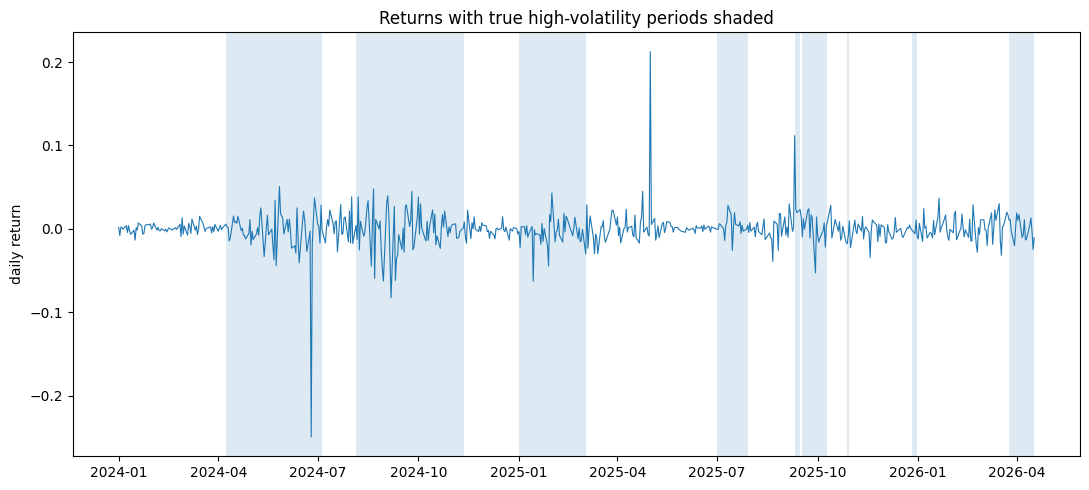

In [2]:
import matplotlib.pyplot as plt

# Plot returns and shade the true high-vol regime (for intuition)
dates = df["date"]
high = df["true_regime"].values == 1

plt.figure(figsize=(11, 5))
plt.plot(dates, df["return"], linewidth=0.8)

in_high = False
start = None
for i, is_high in enumerate(high):
    if is_high and not in_high:
        in_high = True
        start = i
    if in_high and (not is_high or i == len(high) - 1):
        end = i if not is_high else i + 1
        plt.axvspan(dates.iloc[start], dates.iloc[end - 1], alpha=0.15)
        in_high = False

plt.title("Returns with true high-volatility periods shaded")
plt.ylabel("daily return")
plt.tight_layout()
plt.show()

In [3]:
from scipy.special import gammaln

def systematic_resample(weights, rng):
    N = len(weights)
    positions = (rng.random() + np.arange(N)) / N
    cumsum = np.cumsum(weights)
    idx = np.zeros(N, dtype=int)
    i = j = 0
    while i < N:
        if positions[i] < cumsum[j]:
            idx[i] = j
            i += 1
        else:
            j += 1
    return idx

def student_t_logpdf(x, scale, nu=5):
    # Student-t with mean 0, scaled by "scale" (sigma-like)
    return (
        gammaln((nu + 1) / 2) - gammaln(nu / 2)
        - 0.5 * (np.log(nu * np.pi) + 2 * np.log(scale))
        - ((nu + 1) / 2) * np.log1p((x / scale) ** 2 / nu)
    )

def particle_filter_vol_regime(
    returns,
    N=4000,
    P=np.array([[0.97, 0.03],
                [0.06, 0.94]]),
    mu=np.array([np.log(0.008), np.log(0.025)]),
    phi=0.95,
    q=0.18,
    nu=5,
    resample_ess_ratio=0.5,
    seed=123
):
    rng = np.random.default_rng(seed)
    T = len(returns)

    # Particles carry: regime and log_sigma
    regime = rng.integers(0, 2, size=N)
    log_sigma = mu[regime] + rng.normal(0, 0.1, size=N)
    w = np.ones(N) / N

    prob_high = np.zeros(T)
    sigma_hat = np.zeros(T)
    ess_track = np.zeros(T)

    for t in range(T):
        # 1) Regime transition
        u = rng.random(N)
        mask0 = (regime == 0)
        new_regime = regime.copy()
        new_regime[mask0] = (u[mask0] > P[0, 0]).astype(int)       # 0->1 if u > p00
        mask1 = ~mask0
        new_regime[mask1] = 1 - (u[mask1] > P[1, 1]).astype(int)   # 1->0 if u > p11
        regime = new_regime

        # 2) Volatility transition (AR1 to regime mean)
        eps = rng.normal(0, q, size=N)
        m = mu[regime]
        log_sigma = m + phi * (log_sigma - m) + eps
        sigma = np.exp(log_sigma)

        # 3) Weight update (Student-t likelihood)
        r = returns[t]
        loglik = student_t_logpdf(r, sigma, nu=nu)

        logw = np.log(w) + loglik
        logw -= np.max(logw)            # stabilize
        w = np.exp(logw)
        w /= np.sum(w)

        prob_high[t] = w[regime == 1].sum()
        sigma_hat[t] = np.sum(w * sigma)

        ess = 1.0 / np.sum(w * w)
        ess_track[t] = ess

        # 4) Resample if ESS too low
        if ess < resample_ess_ratio * N:
            idx = systematic_resample(w, rng)
            regime = regime[idx]
            log_sigma = log_sigma[idx]
            w = np.ones(N) / N

    return prob_high, sigma_hat, ess_track

prob_high, sigma_hat, ess_track = particle_filter_vol_regime(df["return"].values)

print("Last 5 P(high-vol):", np.round(prob_high[-5:], 3))
print("Mean ESS:", int(np.mean(ess_track)))

Last 5 P(high-vol): [0.268 0.281 0.246 0.324 0.312]
Mean ESS: 2721


In [4]:
from sklearn.metrics import roc_auc_score, f1_score

y = df["true_regime"].values

# Rolling baseline
roll_vol = df["return"].rolling(20).std().bfill().values
auc_roll = roc_auc_score(y, roll_vol)

# Particle filter probability
auc_pf = roc_auc_score(y, prob_high)

# Best F1 thresholds (for a fair “if you had to threshold it” view)
best_pf = (0.0, None)
for thr in np.linspace(0, 1, 101):
    f1 = f1_score(y, (prob_high >= thr).astype(int))
    if f1 > best_pf[0]:
        best_pf = (f1, thr)

qs = np.quantile(roll_vol, np.linspace(0, 1, 201))
best_roll = (0.0, None)
for thr in qs:
    f1 = f1_score(y, (roll_vol >= thr).astype(int))
    if f1 > best_roll[0]:
        best_roll = (f1, thr)

metrics = pd.DataFrame({
    "method": ["Rolling 20d volatility", "Particle filter (Student-t)"],
    "AUC": [auc_roll, auc_pf],
    "Best F1": [best_roll[0], best_pf[0]],
    "Best threshold": [best_roll[1], best_pf[1]]
})

display(metrics) ## .to_markdown(index=False)

,method,AUC,Best F1,Best threshold
0,Rolling 20d volatility,0.723420,0.647303,0.006981
1,Particle filter (Student-t),0.744276,0.660163,0.280000


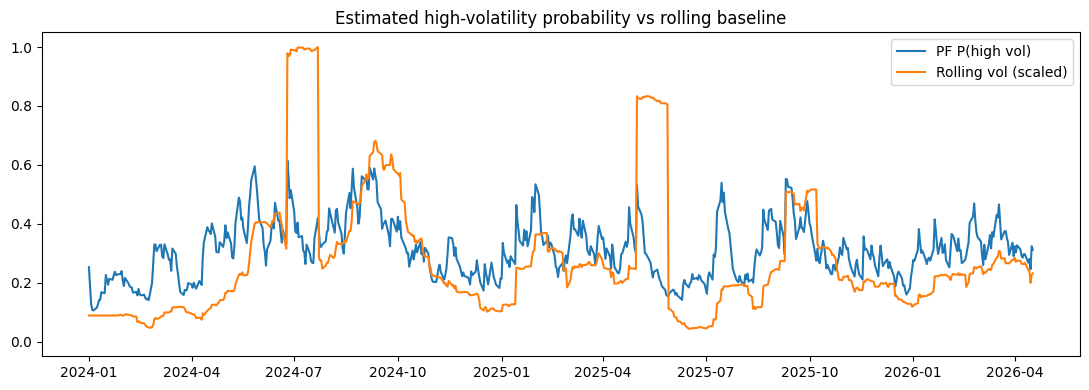

In [5]:
# Rolling baseline (20-day volatility)
roll_vol = df["return"].rolling(20).std().bfill().values

plt.figure(figsize=(11, 4))
plt.plot(df["date"], prob_high, label="PF P(high vol)")
plt.plot(df["date"], roll_vol / roll_vol.max(), label="Rolling vol (scaled)")
plt.ylim(-0.05, 1.05)
plt.title("Estimated high-volatility probability vs rolling baseline")
plt.tight_layout()
plt.legend()
plt.show()